# 01 — Análise Exploratória da Série Temporal de Vendas

Este notebook é a primeira etapa do laboratório de forecasting da AdventureWorks.

## Pergunta central

**Antes de tentar prever o futuro, o que precisamos entender sobre o comportamento histórico das vendas?**

Neste notebook ainda **não vamos construir nenhum modelo de forecast**.

O objetivo é investigar:

- completude temporal;
- tendência;
- sazonalidade;
- variação residual;
- limitações da série.

Ao final, queremos responder:

> Que características um modelo de forecasting precisará considerar para representar adequadamente esta série?


## 1. Bibliotecas

Usaremos `pandas`, `matplotlib`, `sqlalchemy` e `statsmodels`.


In [52]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from statsmodels.tsa.seasonal import seasonal_decompose
from IPython.display import display

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Conexão com o Data Warehouse

O notebook consulta a camada `analytics` do PostgreSQL. Para o laboratório local, usamos os valores de desenvolvimento como fallback; em produção, use variáveis de ambiente ou secrets.

In [53]:
DB_USER = os.getenv("WAREHOUSE_DB_USER", "analytics_user")
DB_PASSWORD = os.getenv("WAREHOUSE_DB_PASSWORD", "analytics_dev")
DB_HOST = os.getenv("WAREHOUSE_DB_HOST", "localhost")
DB_PORT = os.getenv("WAREHOUSE_DB_PORT", "5434")
DB_NAME = os.getenv("WAREHOUSE_DB_NAME", "analytics")

DATABASE_URL = (
    f"postgresql+psycopg://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

engine = create_engine(DATABASE_URL)

pd.read_sql("select 1 as ok", engine)

,ok
0,1


## 3. Carregamento da série mensal

A fonte oficial do laboratório é `analytics.fct_sales_monthly`. O notebook não recria regras de negócio já consolidadas no dbt.

In [54]:
query = """
select *
from analytics.fct_sales_monthly
order by sales_month
"""

df = pd.read_sql(query, engine)
df["sales_month"] = pd.to_datetime(df["sales_month"])
df = df.sort_values("sales_month").reset_index(drop=True)

df.head()

,sales_month,orders_count,customers_count,units_sold,gross_sales,discount_amount,net_sales,average_order_value
0,2022-05-01,47,47,829,"517,737.44",0.00,"517,737.44","11,015.69"
1,2022-06-01,217,217,2195,"2,002,944.05","1,665.08","2,001,278.97","9,222.48"
2,2022-07-01,215,215,1667,"1,668,946.90",436.40,"1,668,510.50","7,760.51"
3,2022-08-01,189,189,1391,"1,326,249.99",111.88,"1,326,138.11","7,016.60"
4,2022-09-01,250,250,3123,"2,838,030.64","1,621.02","2,836,409.61","11,345.64"


## 4. Inspeção inicial

Antes da análise temporal, verificamos período disponível, quantidade de observações e estrutura da tabela.

In [55]:
print("Shape:", df.shape)
print("Primeiro mês:", df["sales_month"].min())
print("Último mês:", df["sales_month"].max())
print("Quantidade de meses:", len(df))
print("
Colunas:", df.columns.tolist())
print("
Tipos:")
display(df.dtypes)

SyntaxError: unterminated string literal (detected at line 5) (1355002798.py, line 5)

## 5. Continuidade mensal

Uma série mensal precisa ter frequência temporal bem definida. Vamos verificar se há meses ausentes.

In [56]:
expected_months = pd.date_range(
    start=df["sales_month"].min(),
    end=df["sales_month"].max(),
    freq="MS"
)

missing_months = expected_months.difference(df["sales_month"])

if len(missing_months) == 0:
    print("✅ A série mensal é contínua.")
else:
    print("⚠️ Existem meses ausentes:")
    display(pd.DataFrame({"missing_month": missing_months}))

✅ A série mensal é contínua.


## 6. Validação do último período

Uma regra importante em forecasting:

> **O último período disponível deve ser tratado como potencialmente incompleto até que sua completude seja validada.**

Vamos observar os últimos meses e consultar a `fact_sales` para verificar até que data há vendas.

In [57]:
display(df[["sales_month", "net_sales", "orders_count", "units_sold"]].tail(6))

,sales_month,net_sales,orders_count,units_sold
32,2025-01-01,"4,276,427.72",2136,11464
33,2025-02-01,"3,565,879.32",1857,11436
34,2025-03-01,"4,987,901.53",2304,15442
35,2025-04-01,"5,222,758.74",2279,15539
36,2025-05-01,"1,908,059.49",2218,5583
37,2025-06-01,"47,491.55",905,2047


In [58]:
last_month_diagnosis_query = """
select
    date_trunc('month', d.full_date)::date as sales_month,
    min(d.full_date) as first_order_date,
    max(d.full_date) as last_order_date,
    count(distinct d.full_date) as sales_days,
    count(distinct f.sales_order_id) as orders_count,
    sum(f.order_quantity) as units_sold,
    sum(f.net_amount) as net_sales
from analytics.fact_sales f
join analytics.dim_date d
    on f.order_date_id = d.date_id
where d.full_date >= '2025-05-01'
group by 1
order by 1
"""

last_month_diagnosis = pd.read_sql(last_month_diagnosis_query, engine)
last_month_diagnosis

,sales_month,first_order_date,last_order_date,sales_days,orders_count,units_sold,net_sales
0,2025-05-01,2025-05-01,2025-05-31,31,2218,5583,"1,908,059.49"
1,2025-06-01,2025-06-01,2025-06-29,29,905,2047,"47,491.55"


### Decisão metodológica

Neste laboratório, adotamos uma decisão conservadora: **remover o último mês disponível da série utilizada na análise e nos modelos**, pois ele representa o fim da extração e pode não estar completamente fechado.

Isso evita que um período parcial distorça tendência, sazonalidade e previsões futuras.

In [59]:
df_closed = df[df["sales_month"] < df["sales_month"].max()].copy()

print("Último mês da série original:", df["sales_month"].max())
print("Último mês usado na análise:", df_closed["sales_month"].max())
print("Observações utilizadas:", len(df_closed))

Último mês da série original: 2025-06-01 00:00:00
Último mês usado na análise: 2025-05-01 00:00:00
Observações utilizadas: 37


## 7. Visualização da série histórica

A primeira pergunta analítica é:

> Como a receita mensal evoluiu ao longo do tempo?

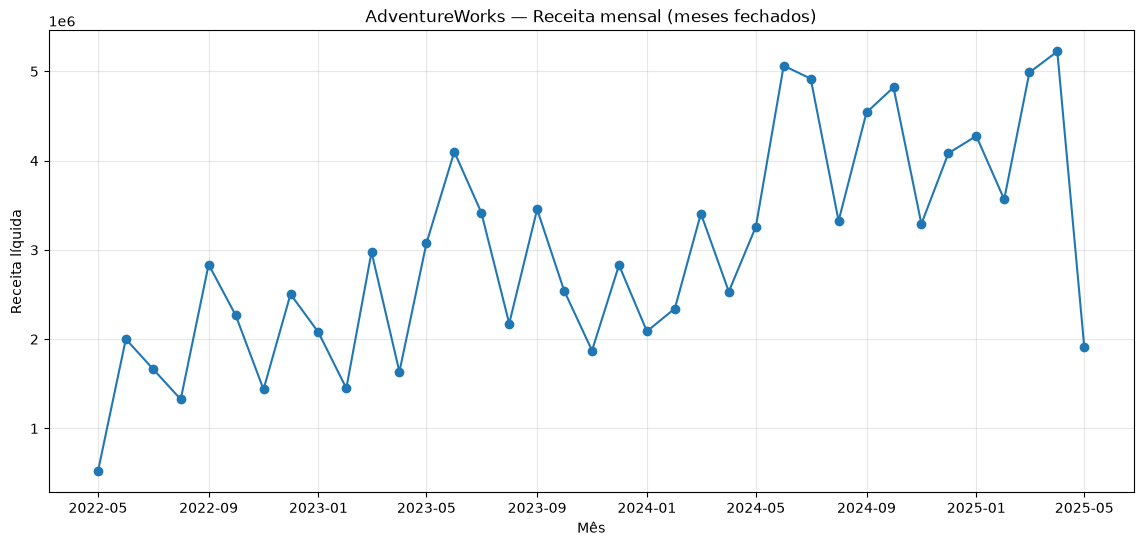

In [60]:
plt.figure(figsize=(14, 6))
plt.plot(df_closed["sales_month"], df_closed["net_sales"], marker="o")
plt.title("AdventureWorks — Receita mensal (meses fechados)")
plt.xlabel("Mês")
plt.ylabel("Receita líquida")
plt.grid(alpha=0.3)
plt.show()

### Primeira leitura

A série sugere crescimento ao longo do período, mas apresenta oscilações relevantes mês a mês. Precisamos separar melhor **tendência** de **variação de curto prazo**.

## 8. Tendência com médias móveis

A média móvel suaviza parte do ruído mensal. A janela de 3 meses reage mais rapidamente; a de 6 meses mostra melhor a direção de médio prazo.

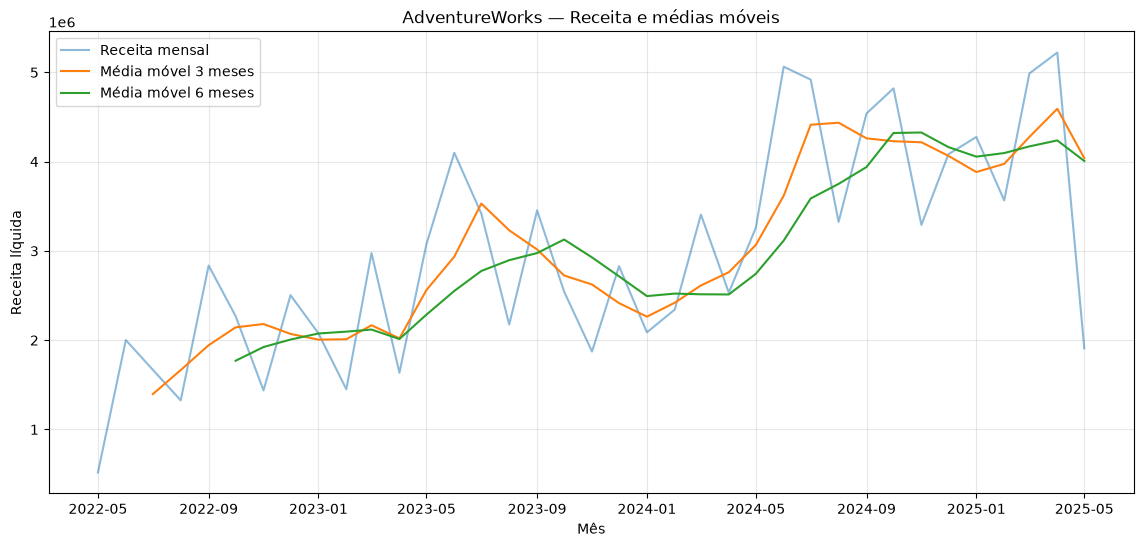

In [61]:
df_closed["net_sales_ma_3"] = df_closed["net_sales"].rolling(window=3).mean()
df_closed["net_sales_ma_6"] = df_closed["net_sales"].rolling(window=6).mean()

plt.figure(figsize=(14, 6))
plt.plot(df_closed["sales_month"], df_closed["net_sales"], label="Receita mensal", alpha=0.5)
plt.plot(df_closed["sales_month"], df_closed["net_sales_ma_3"], label="Média móvel 3 meses")
plt.plot(df_closed["sales_month"], df_closed["net_sales_ma_6"], label="Média móvel 6 meses")
plt.title("AdventureWorks — Receita e médias móveis")
plt.xlabel("Mês")
plt.ylabel("Receita líquida")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Conclusão sobre tendência

Visualmente, a média móvel de médio prazo cresce ao longo da série. Isso indica uma **tendência estrutural de crescimento da receita**. A tendência não é perfeitamente linear, então um modelo futuro deverá lidar com crescimento e oscilações ao mesmo tempo.

## 9. Primeira investigação de sazonalidade

Sazonalidade significa que determinados padrões tendem a se repetir em intervalos regulares. Como a série é mensal, investigamos se certos meses do ano tendem a ser mais fortes ou mais fracos.

In [62]:
df_closed["month_number"] = df_closed["sales_month"].dt.month
df_closed["month_name"] = df_closed["sales_month"].dt.strftime("%b")

monthly_pattern = (
    df_closed
    .groupby(["month_number", "month_name"], as_index=False)
    .agg(
        avg_net_sales=("net_sales", "mean"),
        median_net_sales=("net_sales", "median"),
        observations=("net_sales", "size")
    )
    .sort_values("month_number")
)

monthly_pattern

,month_number,month_name,avg_net_sales,median_net_sales,observations
0,1,Jan,"2,813,697.26","2,087,872.46",3
1,2,Feb,"2,453,007.59","2,343,260.23",3
2,3,Mar,"3,790,229.06","3,407,037.41",3
3,4,Apr,"3,130,138.99","2,533,057.41",3
4,5,May,"2,189,685.22","2,491,331.15",4
5,6,Jun,"3,721,477.24","4,099,354.36",3
6,7,Jul,"3,335,014.85","3,417,953.87",3
7,8,Aug,"2,275,690.47","2,175,637.22",3
8,9,Sep,"3,610,130.18","3,454,151.94",3
9,10,Oct,"3,211,418.22","2,544,091.11",3


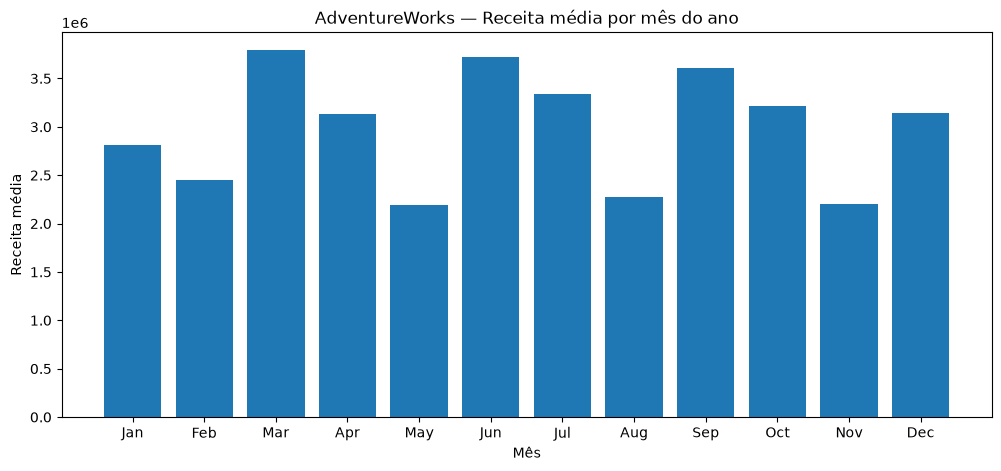

In [63]:
plt.figure(figsize=(12, 5))
plt.bar(monthly_pattern["month_name"], monthly_pattern["avg_net_sales"])
plt.title("AdventureWorks — Receita média por mês do ano")
plt.xlabel("Mês")
plt.ylabel("Receita média")
plt.show()

### Cuidado metodológico

A série tem tendência de crescimento. Portanto, uma média simples por mês pode misturar **efeito de crescimento** e **efeito sazonal**. Este gráfico fornece apenas um indício inicial.

## 10. Comparação do padrão mensal entre anos

Agora avaliamos se os picos e vales acontecem em meses semelhantes, mesmo quando cada ano está em um nível diferente de receita.

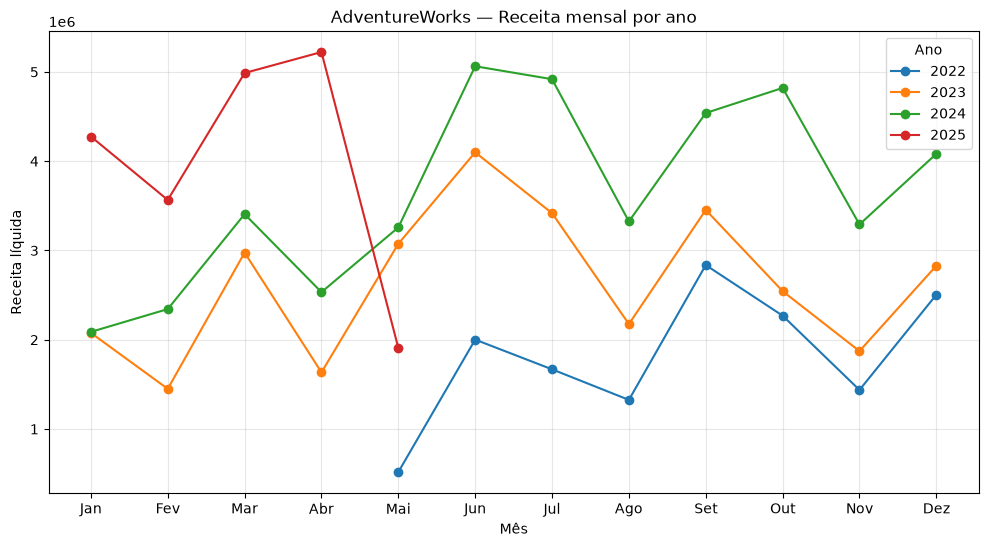

In [64]:
seasonality = df_closed.copy()
seasonality["year"] = seasonality["sales_month"].dt.year
seasonality["month"] = seasonality["sales_month"].dt.month

plt.figure(figsize=(12, 6))

for year, group in seasonality.groupby("year"):
    plt.plot(group["month"], group["net_sales"], marker="o", label=str(year))

plt.xticks(
    range(1, 13),
    ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
)
plt.title("AdventureWorks — Receita mensal por ano")
plt.xlabel("Mês")
plt.ylabel("Receita líquida")
plt.legend(title="Ano")
plt.grid(alpha=0.3)
plt.show()

### Conclusão sobre sazonalidade

Os anos apresentam formatos de oscilação semelhantes em vários pontos. Isso fornece **evidências de sazonalidade anual**.

Como o histórico possui pouco mais de três anos, a sazonalidade deve ser tratada como **evidência consistente**, não como prova estatística definitiva.

## 11. Decomposição da série temporal

Vamos decompor a série em:

**Observed = Trend + Seasonal + Residual**

- `Observed`: série original;
- `Trend`: movimento estrutural de longo prazo;
- `Seasonal`: padrão recorrente;
- `Residual`: variação não explicada pelos componentes anteriores.

Usaremos decomposição aditiva com período sazonal de 12 meses.

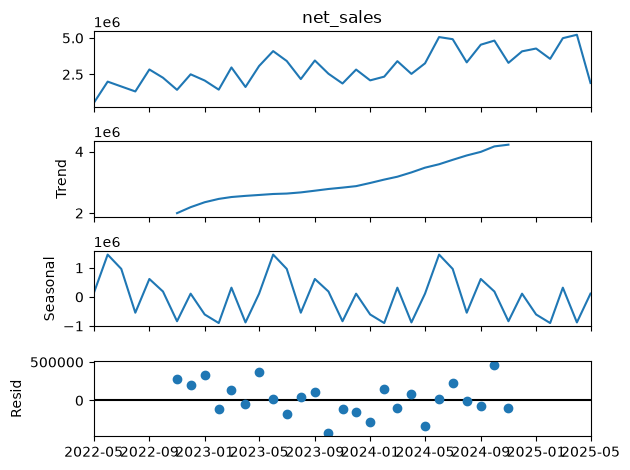

In [65]:
sales_series = (
    df_closed
    .set_index("sales_month")["net_sales"]
    .asfreq("MS")
)

decomposition = seasonal_decompose(
    sales_series,
    model="additive",
    period=12
)

decomposition.plot()
plt.show()

### Interpretação da decomposição

- **Trend:** reforça a trajetória de crescimento da série.
- **Seasonal:** mostra um padrão recorrente dentro do ciclo anual.
- **Residual:** representa variação não explicada por tendência e sazonalidade.

Idealmente, os resíduos não devem apresentar um padrão sistemático evidente.

## 12. O que aprendemos sobre a série?

### Tendência
A receita apresenta uma **tendência estrutural de crescimento**.

### Sazonalidade
Existem **evidências de sazonalidade anual**, com padrões semelhantes de picos e vales em diferentes anos.

### Ruído
Ainda existe variação relevante não explicada apenas por tendência e sazonalidade.

### Completude temporal
O último mês foi removido da série analítica por representar o final da extração e poder estar incompleto.

### Implicação para forecasting
Um modelo futuro deverá lidar, pelo menos, com:

- nível;
- tendência;
- sazonalidade.

Esse diagnóstico torna modelos como Holt-Winters candidatos interessantes para etapas posteriores.

## 13. Limitações

- pouco mais de três anos de histórico;
- poucas repetições de cada mês do calendário;
- base AdventureWorks demonstrativa;
- padrões históricos não garantem comportamento futuro;
- ainda não realizamos backtesting;
- ainda não medimos erro de previsão.

Este notebook é um **diagnóstico exploratório**, não uma validação de modelo preditivo.

## 14. Próxima etapa — `02_baselines.ipynb`

A próxima pergunta será:

> Qual é a previsão mais simples que conseguimos construir e como sabemos se ela é boa?

Vamos implementar:

1. **Naive Forecast** — próximo mês = último mês observado;
2. **Seasonal Naive** — próximo mês = mesmo mês do ano anterior;
3. **Moving Average Forecast** — previsão baseada na média recente;
4. separação treino/teste;
5. métricas de erro: MAE, RMSE e WAPE.

Esses modelos serão nosso **baseline**. Um modelo mais sofisticado só será interessante se conseguir superá-los.